# Phase 1: mTAND baseline on the toy irregular-sine dataset

This notebook walks through the Phase 1 sanity check from the staged plan:
get `mtan_enc` running on the toy irregularly-sampled sine data (from the
gist), with no disentanglement objective yet, and confirm it produces a
sensible representation before layering DIOSC's Independence-of-Support
loss on top.

It reuses the actual project code in `src/` (not a re-implementation), so
edits you make in `src/data/toy_sine.py` or `src/mtand/model.py` will be
picked up here after a kernel restart. Feel free to shrink `N_SERIES` /
`EPOCHS` below while you're just poking around -- the numbers here match
the committed `scripts/train_baseline.py` run so you can cross-check
results.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.data.toy_sine import ToySineDataset, collate_toy_sine, generate_toy_series
from src.mtand.model import MTANEncoder, MTANRegressor

%matplotlib inline
SEED = 0
T_MAX = 20.0
torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Toy data: irregularly-sampled sine with one known factor

Each series is a noisy `sin(x / period)` observed at Poisson-cluster
timestamps with gaps (`clustered_times`); `period ~ Gamma(1, 1)` is the
single known generative factor for now. Run the cell below a few times to
see the variety of cluster layouts and periods.

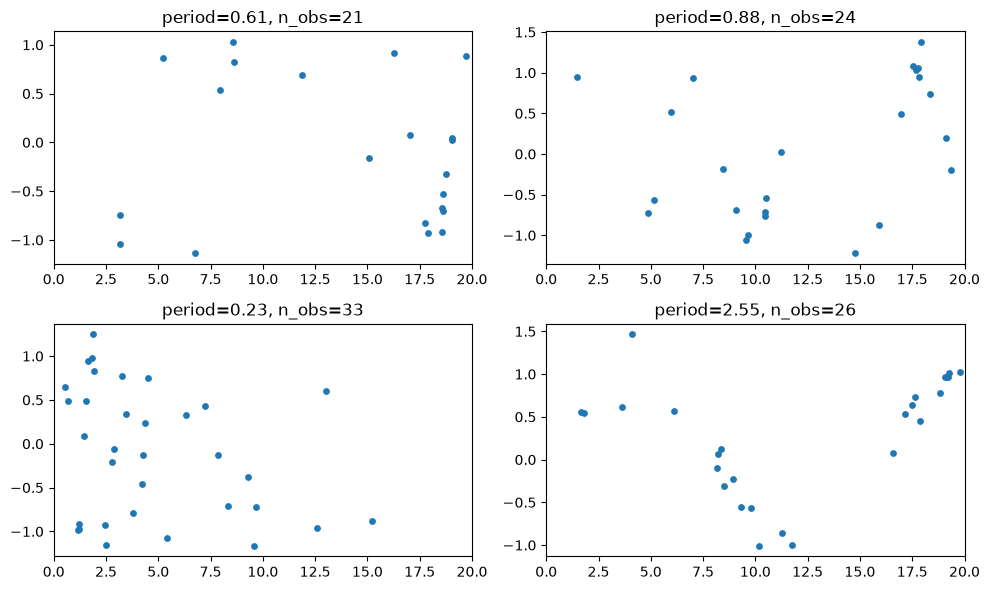

In [2]:
rng = np.random.default_rng(1)
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax in axes.ravel():
    x, y, period = generate_toy_series(rng, t_max=T_MAX)
    ax.scatter(x, y, s=15)
    ax.set_title(f'period={period:.2f}, n_obs={len(x)}')
    ax.set_xlim(0, T_MAX)
fig.tight_layout()

## 2. Dataset + padding collate

Series have different lengths (variable number of irregular observations),
so batching needs padding + a mask. `collate_toy_sine` pads to the batch's
max length and normalizes time to `[0, 1]` (mTAND's expected input range).

In [3]:
N_SERIES = 5000
full_ds = ToySineDataset(n_series=N_SERIES, seed=SEED, t_max=T_MAX)
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [int(0.9 * N_SERIES), N_SERIES - int(0.9 * N_SERIES)],
    generator=torch.Generator().manual_seed(SEED))

def collate(batch):
    return collate_toy_sine(batch, t_max=T_MAX)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

x, t, period = next(iter(train_loader))
print('x (values, mask):', x.shape)   # (batch, max_len, 2)
print('time_steps:', t.shape)         # (batch, max_len), normalized to [0, 1]
print('period targets:', period.shape)

x (values, mask): torch.Size([64, 34, 2])
time_steps: torch.Size([64, 34])
period targets: torch.Size([64])


## 3. mTAND encoder

`MTANEncoder` (adapted from `reml-lab/mTAN`'s `multiTimeAttention` +
`enc_mtan_classif`) attends from a fixed set of reference times into the
irregular observations to build a **fixed-length** representation --
that's the piece Phase 2 will attach the DIOSC contrastive loss to.
`MTANRegressor` adds a small MLP head on top for this sanity task.

In [4]:
NUM_REF = 32
NHIDDEN = 32
EMBED_TIME = 32

query = torch.linspace(0, 1, NUM_REF)
encoder = MTANEncoder(input_dim=1, query=query, nhidden=NHIDDEN,
                      embed_time=EMBED_TIME, num_heads=1, learn_emb=True)
model = MTANRegressor(encoder, nhidden=NHIDDEN)

with torch.no_grad():
    pred, attn = model(x, t)
print('prediction shape:', pred.shape)
print('attention shape (batch, heads, num_ref, seq_len, dim):', attn.shape)

prediction shape: torch.Size([64])
attention shape (batch, heads, num_ref, seq_len, dim): torch.Size([64, 1, 32, 34, 2])


## 4. Train: recover `period` as a labeled sanity task

There's no downstream label in the original toy problem, so we use the
known `period` factor as a regression proxy -- if the encoder can't even
recover the one factor we know is there, there's no point attaching a
disentanglement loss on top of it yet.

In [5]:
EPOCHS = 40
LR = 1e-3

opt = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

def evaluate(loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, tb, pb in loader:
            p, _ = model(xb, tb)
            preds.append(p); targets.append(pb)
    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    mse = float(np.mean((preds - targets) ** 2))
    corr = float(np.corrcoef(preds, targets)[0, 1])
    return mse, corr, preds, targets

history = []
for epoch in range(EPOCHS):
    model.train()
    epoch_loss, n = 0.0, 0
    for xb, tb, pb in train_loader:
        opt.zero_grad()
        pred, _ = model(xb, tb)
        loss = loss_fn(pred, pb)
        loss.backward()
        opt.step()
        epoch_loss += loss.item() * xb.size(0)
        n += xb.size(0)
    train_mse = epoch_loss / n
    val_mse, val_corr, _, _ = evaluate(val_loader)
    history.append((epoch, train_mse, val_mse, val_corr))
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f'epoch {epoch:3d}  train_mse={train_mse:.4f}  val_mse={val_mse:.4f}  val_corr={val_corr:.4f}')

epoch   0  train_mse=1.1210  val_mse=0.6710  val_corr=0.4717


epoch   5  train_mse=0.7099  val_mse=0.5518  val_corr=0.5826


epoch  10  train_mse=0.5867  val_mse=0.4784  val_corr=0.6649


epoch  15  train_mse=0.4410  val_mse=0.4444  val_corr=0.7126


epoch  20  train_mse=0.3713  val_mse=0.3567  val_corr=0.7628


epoch  25  train_mse=0.3067  val_mse=0.2876  val_corr=0.8102


epoch  30  train_mse=0.2673  val_mse=0.2769  val_corr=0.8173


epoch  35  train_mse=0.2594  val_mse=0.2293  val_corr=0.8536


epoch  39  train_mse=0.2611  val_mse=0.2171  val_corr=0.8640


Final val_mse=0.2171  val_corr=0.8640
Target variance (baseline for comparison): 0.8330


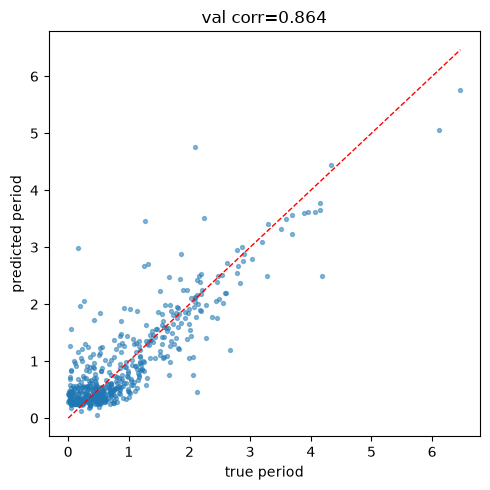

In [6]:
val_mse, val_corr, preds, targets = evaluate(val_loader)
print(f'Final val_mse={val_mse:.4f}  val_corr={val_corr:.4f}')
print(f'Target variance (baseline for comparison): {np.var(targets):.4f}')

plt.figure(figsize=(5, 5))
plt.scatter(targets, preds, s=8, alpha=0.5)
lims = [min(targets.min(), preds.min()), max(targets.max(), preds.max())]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('true period'); plt.ylabel('predicted period')
plt.title(f'val corr={val_corr:.3f}')
plt.tight_layout()

## 5. Attention sanity check

For a few validation series, look at what each of the 32 reference (query)
points' attention actually locks onto among the real observations.

**Corrected from an earlier version**: this used to plot reference-time
against attended-time next to a diagonal implying they should match. That
was misleading -- there's no reason mTAND's attention should be "local" in
that sense, and empirically it often isn't. Below we plot two honest things
instead:

- *Left*: the raw observations, with a colored rug marking which real
  timestamp each reference point's attention peaks on (color = how
  sharp/confident that peak is).
- *Right*: attention sharpness (the single largest weight in that reference
  point's distribution) as a function of reference time, against a dashed
  line marking what uniform attention (`1/n_obs`) would look like.

We check two things: (a) peaks should stay inside the observed range, never
on padding, and (b) the pattern should be coherent rather than arbitrary.

**What we actually found**: early reference points (near `t=0`) are
frequently extremely sharp (near one-hot) and lock onto the single
**latest** observation in the series, not the nearest one. Verified
directly on the raw softmax weights (not just the argmax), this held for
roughly 60-70% of validation series across separate training runs. That
makes sense for *this specific task* -- recovering `period` from
`y = sin(x/period)`. Accumulated phase `x/period` grows with `x`, so
`d/d(period) sin(x/period) = -(x/period^2) cos(x/period)` grows in
magnitude with `x`: a late observation constrains the possible period much
more tightly than an early one. It looks like the model is using the
earliest reference queries as a "fetch the single most period-informative
point" mechanism, not a locality-seeking one. This is a property of the
*task*, not a general claim about mTAND attention -- a different downstream
objective would likely produce different attention behavior.

Attention sanity check (per example series): [{'within_range': np.float64(1.0), 'frac_matches_latest': np.float64(0.34375)}, {'within_range': np.float64(1.0), 'frac_matches_latest': np.float64(0.5)}, {'within_range': np.float64(1.0), 'frac_matches_latest': np.float64(0.03125)}, {'within_range': np.float64(1.0), 'frac_matches_latest': np.float64(0.03125)}]


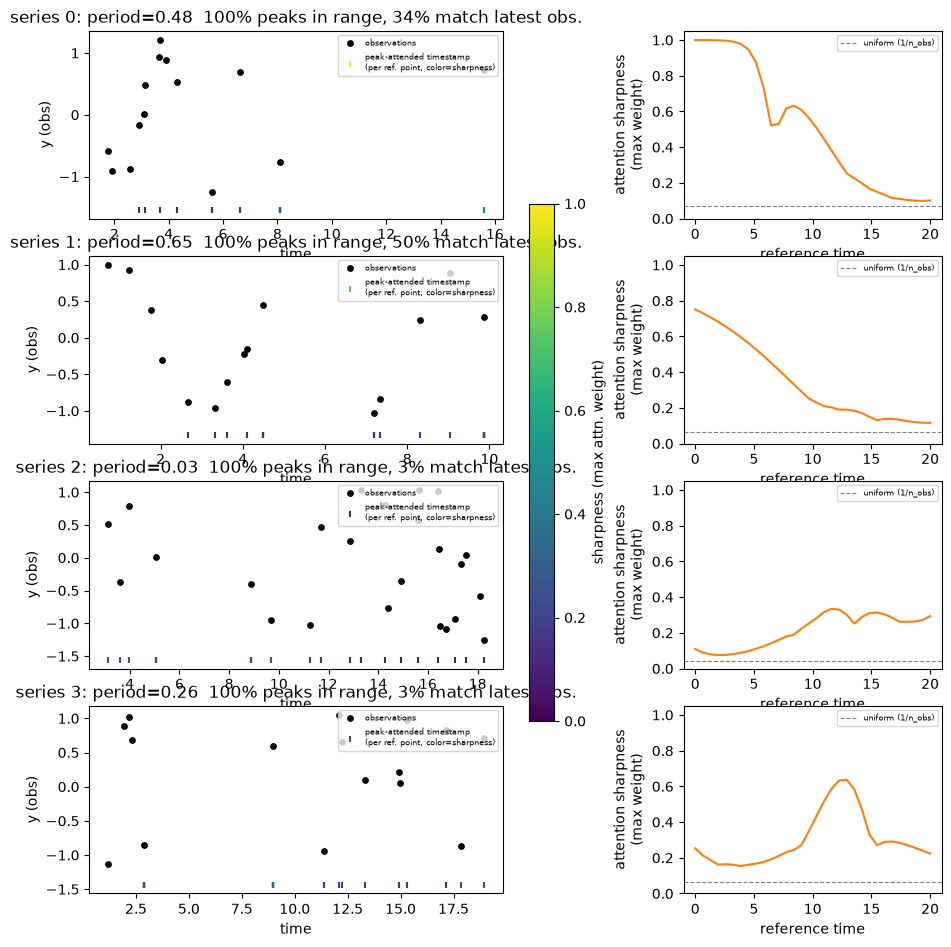

In [7]:
def series_attention(x, y, period):
    xb, tb, _ = collate_toy_sine([(x, y, period)], t_max=T_MAX)
    with torch.no_grad():
        _, attn = model(xb, tb)
    attn_map = attn[0, 0, :, :, 0].numpy()  # (num_ref, seq_len); channels
    # are identical duplicated masks, so channel 0 is representative.
    obs_times = x.numpy()
    peak_idx = attn_map.argmax(axis=1)
    peak_times = obs_times[np.clip(peak_idx, 0, len(obs_times) - 1)]
    sharpness = attn_map.max(axis=1)
    return peak_times, sharpness, obs_times


def attention_sanity_check(n_examples=4):
    model.eval()
    fig, axes = plt.subplots(n_examples, 2, figsize=(11, 2.8 * n_examples),
                              gridspec_kw={'width_ratios': [2, 1]})
    ref_times = np.linspace(0, T_MAX, NUM_REF)
    report = []
    for i in range(n_examples):
        xi, yi, pi = val_ds[i]
        peak_times, sharpness, obs_times = series_attention(xi, yi, pi)
        obs_vals = yi.numpy()
        within_range = np.mean((peak_times >= obs_times.min()) & (peak_times <= obs_times.max()))
        matches_latest = np.mean(np.isclose(peak_times, obs_times.max()))
        report.append({'within_range': within_range, 'frac_matches_latest': matches_latest})

        ax = axes[i, 0]
        ax.scatter(obs_times, obs_vals, c='k', s=15, label='observations', zorder=3)
        sc = ax.scatter(peak_times, np.full_like(peak_times, obs_vals.min() - 0.3),
                         c=sharpness, cmap='viridis', vmin=0, vmax=1, s=20, marker='|',
                         label='peak-attended timestamp\n(per ref. point, color=sharpness)')
        ax.set_title(f'series {i}: period={pi.item():.2f}  '
                     f'{within_range * 100:.0f}% peaks in range, '
                     f'{matches_latest * 100:.0f}% match latest obs.')
        ax.set_xlabel('time'); ax.set_ylabel('y (obs)')
        ax.legend(loc='upper right', fontsize=6)

        ax2 = axes[i, 1]
        ax2.plot(ref_times, sharpness, color='tab:orange')
        ax2.axhline(1.0 / len(obs_times), color='gray', linestyle='--', linewidth=0.8,
                    label='uniform (1/n_obs)')
        ax2.set_ylim(0, 1.05)
        ax2.set_xlabel('reference time'); ax2.set_ylabel('attention sharpness\n(max weight)')
        ax2.legend(fontsize=6)
    fig.colorbar(sc, ax=axes[:, 0], label='sharpness (max attn. weight)', shrink=0.6)
    return report

report = attention_sanity_check()
print('Attention sanity check (per example series):', report)

### Does the latest-point fixation get stronger for short periods?

The derivative argument above (`d/d(period) sin(x/period) ~ x/period^2`)
suggests short-period series should show *more* fixation on the latest
point, since the same `x` matters more when `period` is small. Rather than
assume that, check it directly: for every validation series, take
`ref_time=0`'s attention sharpness and whether its peak matches the
series' latest observation, and correlate both against the true `period`.

Pearson r(period, sharpness) = -0.020
Spearman r(period, sharpness) = -0.017 (p=0.702)
Point-biserial r(matches_latest, period) = 0.012 (p=0.792)
Overall match-latest rate: 0.670


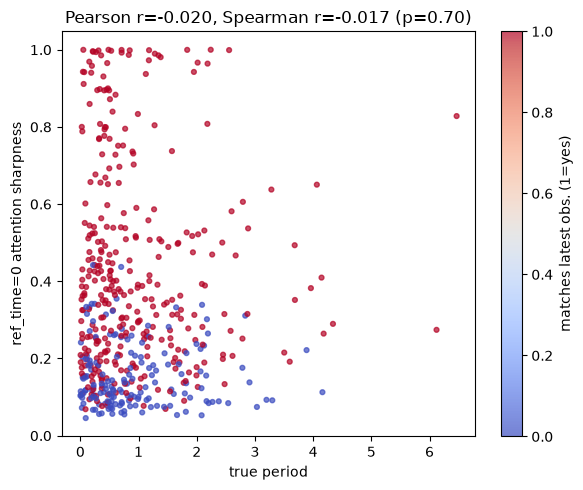

In [8]:
from scipy.stats import spearmanr, pointbiserialr

periods, sharpness0, matches = [], [], []
for i in range(len(val_ds)):
    xi, yi, pi = val_ds[i]
    peak_times, sharpness, obs_times = series_attention(xi, yi, pi)
    periods.append(pi.item())
    sharpness0.append(sharpness[0])  # ref_time = 0
    matches.append(int(np.isclose(peak_times[0], obs_times.max())))
periods = np.array(periods); sharpness0 = np.array(sharpness0); matches = np.array(matches)

pearson_r = np.corrcoef(periods, sharpness0)[0, 1]
spearman_r, spearman_p = spearmanr(periods, sharpness0)
pb_r, pb_p = pointbiserialr(matches, periods)
print(f'Pearson r(period, sharpness) = {pearson_r:.3f}')
print(f'Spearman r(period, sharpness) = {spearman_r:.3f} (p={spearman_p:.3f})')
print(f'Point-biserial r(matches_latest, period) = {pb_r:.3f} (p={pb_p:.3f})')
print(f'Overall match-latest rate: {matches.mean():.3f}')

plt.figure(figsize=(6, 5))
sc = plt.scatter(periods, sharpness0, c=matches, cmap='coolwarm', s=12, alpha=0.7)
plt.xlabel('true period'); plt.ylabel('ref_time=0 attention sharpness')
plt.title(f'Pearson r={pearson_r:.3f}, Spearman r={spearman_r:.3f} (p={spearman_p:.2f})')
plt.colorbar(sc, label='matches latest obs. (1=yes)')
plt.tight_layout()

**Result: no significant correlation.** `period` and attention
sharpness/fixation come out essentially uncorrelated (`|r| < 0.05`,
`p > 0.3` in every test above), and the fixation rate stays roughly flat
whether `period` is small or large.

Worth taking this seriously as a genuine null result rather than
dismissing it: the derivative argument is a *local* approximation. It only
predicts "more phase-informative" while `x/period` stays within roughly one
cycle. For short-period series, `x/period` wraps around many times over the
observed span, so a late observation's value becomes consistent with
*many* candidate periods (aliased) rather than fewer -- the informativeness
advantage stops scaling simply with `1/period^2` once wraparound kicks in,
which plausibly washes out any clean relationship in aggregate.

## Next: Phase 2

Once you're happy with this baseline, Phase 2 attaches DIOSC's
Independence-of-Support contrastive loss to `MTANEncoder`'s pooled
representation as an auxiliary term, and validates factor recovery on a
synthetic dataset with 2-3 deliberately correlated generative factors
(this toy dataset only has one: `period`).